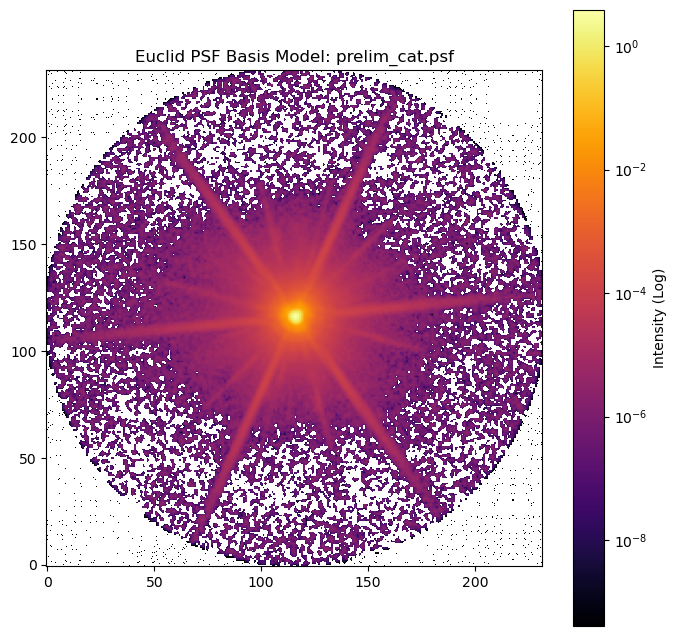

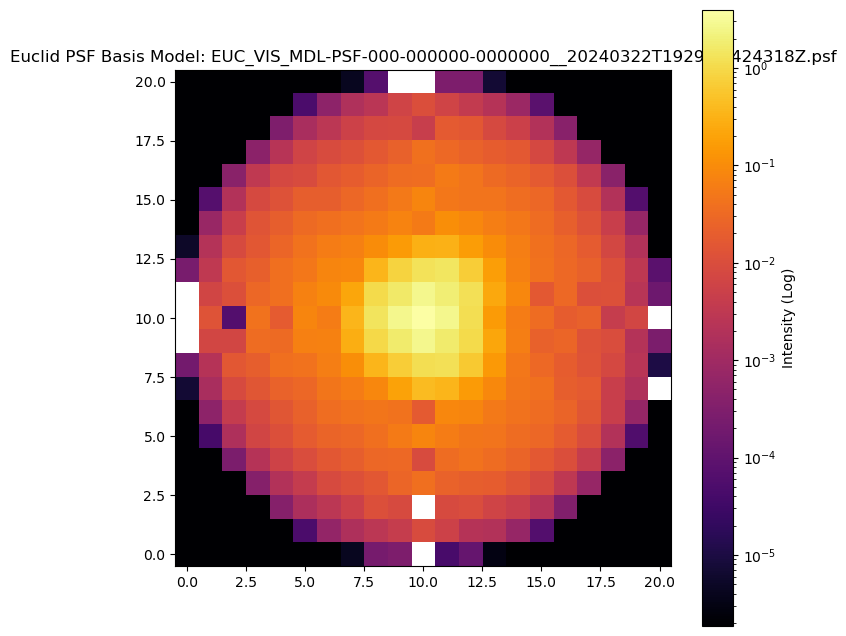

In [17]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

def view_psf_model(psf_file):
    """Reads the PSF model file and displays the primary basis function."""
    with fits.open(psf_file) as hdul:
        # PSFEx stores the data in the second HDU (index 1)
        data = hdul[1].data
        
        psf_basis = data['PSF_MASK'][0]
        
        if psf_basis.ndim == 3:
            psf_image = psf_basis[0]
        else:
            psf_image = psf_basis

        plt.figure(figsize=(8, 8))
        plt.imshow(np.arcsinh(psf_image * 100), origin='lower', cmap='inferno',norm=LogNorm())
        plt.title(f"Euclid PSF Basis Model: {psf_file}")
        plt.colorbar(label='Intensity (Log)')
        plt.show()

view_psf_model("prelim_cat.psf")
view_psf_model("EUC_VIS_MDL-PSF-000-000000-0000000__20240322T192915.424318Z.psf")

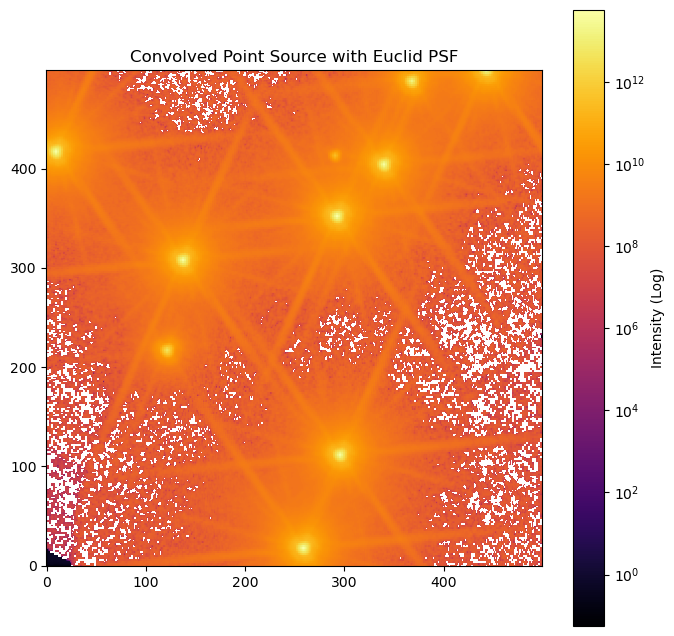

In [24]:
# create a ponit source image with a single bright star in the center
def create_point_source_image(size=500, star_flux=1e5):
    image = np.random.random((size, size))
    center = size // 2
    image[center, center] = star_flux
    return image

def create_multiple_point_sources_image(size=500, star_flux=1e5, num_stars=10):
    image = np.random.random((size, size))
    star_fluxes = np.random.uniform(star_flux * 1E-5, star_flux * 1E10, num_stars)
    for _ in range(num_stars):
        x = np.random.randint(0, size)
        y = np.random.randint(0, size)
        image[y, x] = star_fluxes[_]
    return image

# convolve the point source image with the PSF model
from scipy.signal import convolve2d

def convolve_with_psf(image, psf_file):
    with fits.open(psf_file) as hdul:
        data = hdul[1].data
        psf_basis = data['PSF_MASK'][0]
        if psf_basis.ndim == 3:
            psf_image = psf_basis[0]
        else:
            psf_image = psf_basis
    PSF_super = np.zeros((psf_image.shape[0]*2, psf_image.shape[1]*2))
    for i in range(psf_image.shape[0]):
        for j in range(psf_image.shape[1]):
            PSF_super[2*i:2*i+2, 2*j:2*j+2] = psf_image[i, j] / 4.0
        
    convolved_image = convolve2d(image, PSF_super, mode='same')
    return convolved_image

point_source_image = create_multiple_point_sources_image()
convolved_image = convolve_with_psf(point_source_image, "prelim_cat.psf")

plt.figure(figsize=(8, 8))
plt.imshow(convolved_image, origin='lower', cmap='inferno', norm=LogNorm())
plt.title("Convolved Point Source with Euclid PSF")
plt.colorbar(label='Intensity (Log)')
plt.show()